In [1]:
import sys
sys.path.append("/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/pyscripts")
sys.path.append("/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git")
sys.path.append("/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/Python-Scripts")


import numpy as np
import matplotlib.pyplot as plt
from genlc_with_grid import *


In [2]:
# generate test lcs
if __name__ == "__main__":
    try:
        if len(sys.argv) > 1:
            N = str("test_shapes_noncirc_circ_both_shapes")
            # n = int(sys.argv[2])
            # rsrp=int(sys.argv[3])
            n = 1
            rsrp = 10
            maps_path = f"/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/ml_model_test_files/test_shapes_noncirc_circ_both_shapes.npy"
            ldc_ratio_path = f"/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/Data/LDC_RPRS/ldc_ratio_grid_set.npy"
            
            temp_map = np.load(maps_path, mmap_mode='r')
            total_masks = temp_map.shape[0]
            print(f"Detected {total_masks} masks in {maps_path}")
            
            run_simulation_for_masks(maps_path, f"/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/ml_model_test_files//{N}",inrat=rsrp, num_simulations=n, total_masks=total_masks, ldcr_grid_path = ldc_ratio_path)
        else:
            print('give arg: python3 genlc.py [N] [n]')
    except Exception as e:
        print(f"Main Execution Error: {e}")

Detected 271 masks in /home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/ml_model_test_files/test_shapes_noncirc_circ_both_shapes.npy
Generating parameter sets for 271 masks x 1 sims...
🚀 Starting batched simulation...


  0%|                                                                           | 0/271 [00:00<?, ?it/s]/home/iit-t/anaconda3/envs/genenv_gitika/lib/python3.10/site-packages/EightBitTransit/cGridFunctions.py:168: RuntimeWarning: invalid value encountered in scalar power
  amR = (1. - am)**0.25
/home/iit-t/anaconda3/envs/genenv_gitika/lib/python3.10/site-packages/EightBitTransit/cGridFunctions.py:169: RuntimeWarning: invalid value encountered in scalar power
  bmR = (1. - bm)**0.25
/home/iit-t/anaconda3/envs/genenv_gitika/lib/python3.10/site-packages/EightBitTransit/cGridFunctions.py:168: RuntimeWarning: invalid value encountered in scalar power
  amR = (1. - am)**0.25
/home/iit-t/anaconda3/envs/genenv_gitika/lib/python3.10/site-packages/EightBitTransit/cGridFunctions.py:169: RuntimeWarning: invalid value encountered in scalar power
  bmR = (1. - bm)**0.25
/home/iit-t/anaconda3/envs/genenv_gitika/lib/python3.10/site-packages/EightBitTransit/cGridFunctions.py:168: RuntimeWarning: invalid

⏱️ Time taken: 57.02 seconds
⏱️ Time taken: 57.05 seconds
Interpolating final results...
✅ Saved LCs and Meta.


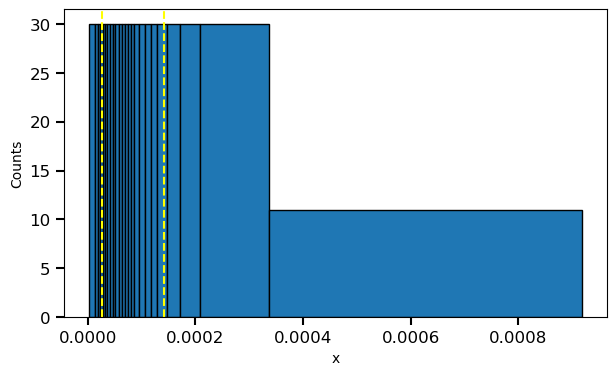

new_folder /home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/ml_model_test_files
time taken is: 0.006931591033935547 minutes


In [1]:
# add noise to generated test lcs
from add_noise_to_lcs import *
if __name__ == "__main__":
    start = time.time()
    kepler_lcs_error_file1="/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Kepler/kepler_folded_lcs_snr50_all_binned_err.npy"
    lc_file1 ="/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/ml_model_test_files/test_shapes_noncirc_circ_both_shapesLC.npy"
    add_noise_to_lcs(lc_file=lc_file1, kepler_lcs_error_file=kepler_lcs_error_file1)
    end = time.time()
    print(f"time taken is: {(end-start)/60} minutes")

In [2]:
# combine the lcs again transit region 
from processing_transit_region import *
if __name__ == "__main__":
    start = time.time()
    folder="/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/ml_model_test_files/Binned_LC/"
    obj = TransitRegionSelector(ltcrv_files_folder=folder)
    obj.find_transit_region_and_save_parallel()
    end = time.time()
    print(f"time taken is: {(end-start)/60} minutes")

    combine_flux(folder, output_file="test_shapes_noncirc_circ_both_shapesLC_hscaled.npy",
             savefolder_path="/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/ml_model_test_files/")

Number of files found is271
Using 24 CPU cores
Total time (minutes): 0.005497916539510091
time taken is: 0.005527122815450033 minutes
Found 271 files
Final shape: (271, 120)
Saved to test_shapes_noncirc_circ_both_shapesLC_hscaled.npy


File found
LCs_arr.shape (271, 120)
ver scaled


100%|█████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 1694.39it/s]

Processed tensor shape: torch.Size([271, 120])
arguments?


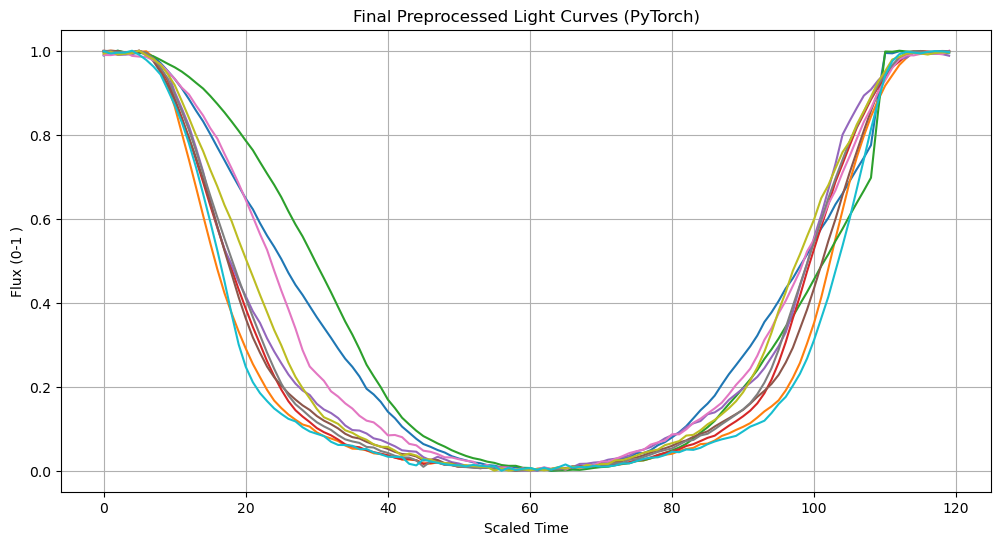

In [20]:
# vertically scale the lcs
from preproclc_hscaled import *
sys.argv[1] = "/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/ml_model_test_files/test_shapes_noncirc_circ_both_shapesLC_hscaled"
if __name__ == "__main__":
    try:
        if len(sys.argv) > 1:
            #Na = str(sys.argv[1])
            Na = str(sys.argv[1])

        try:
            #LCs_arr = np.load(f"LC10/{Na}.npy")
            LCs_arr = np.load(f"{Na}.npy")
            print("File found")
        except FileNotFoundError:
            print("File not found. Using placeholder data for demonstration.")
            LCs_arr = np.ones((10, 100))
            LCs_arr[:, 40:60] = np.linspace(1.0, 0.8, 20)
            LCs_arr[:, 60:80] = np.linspace(0.8, 1.0, 20)

        N, T = LCs_arr.shape
        print('LCs_arr.shape',LCs_arr.shape)

        lcs_tensor = torch.tensor(LCs_arr, dtype=torch.float32)
        ver_scaled = pt_scale_vertically(lcs_tensor)
        print('ver scaled')
        ver_scaled_np = ver_scaled.detach().cpu().numpy()


        np.save(f"{Na}_processed.npy",ver_scaled_np)
        
        plt.figure(figsize=(12, 6))
        for i in tqdm(range(10)):
            plt.plot(ver_scaled_np[i], label=f"LC {i}" if N < 15 else None) 
        plt.title("Final Preprocessed Light Curves (PyTorch)")
        plt.xlabel("Scaled Time")
        plt.ylabel("Flux (0-1 )")
        if N < 15:
            plt.legend()
        plt.grid(True)
        plt.savefig(f"{Na}.png")

        print(f"Processed tensor shape: {ver_scaled.shape}")
        print(f"Computed depths: {depths}")
    except:
        print('arguments?')

In [11]:
# model predictions
import sys
sys.path.append("/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/pyscripts")
sys.path.append("/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git")
sys.path.append("/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/Python-Scripts")

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from models import *

#from obasho_mlmodel_utils import *
from preproclc_hscaled import *
from gauss_noise_utils import *
#from batman_utils import *

n=2
generator = HybridConvNet(n=n)
#generator.load_state_dict(torch.load(f'models/morg4{n}.pth',weights_only=True))
#lc=torch.tensor(np.load('/DATA/s23103/seti/dst/LC10/weird_test_shapes_solidLC.npy'))
generator.load_state_dict(torch.load(f'/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/models/mo4{n}.pth',weights_only=True, map_location='cpu'))



#====================
snr_values = [100000]
snr = snr_values[0]
filepath = f"/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/ml_model_test_files/test_shapes_noncirc_circ_both_shapesLC_hscaled_processed.npy"
ltcrvs = np.load(filepath)
#ltcrvs_noisy = add_gaussian_noise(ltcrvs, snr, seed = 60)
ltcrvs_noisy, sigma = sample_rowwise_gaussian_noise(ltcrvs, snr=snr, seed=42, sigmas_precal= None)
#ltcrvs_sets_noisy.append(ltcrvs_noisy)

outfile1 = f"/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/ml_model_test_files/test_shapes_noncirc_circ_both_shapesLC_hscaled_processed_snr{snr}.npy"
#outfile1_sigma = f"/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/ml_model_test_files/test_shapes_noncirc_circ_both_shapesLC_hscaled_processed_snr{snr}_sigmavals.npy"
np.save(outfile1,ltcrvs_noisy)
#np.save(outfile1_sigma,sigma )
                
lc_filename = outfile1#f"shapes_lcs_test/test_shapes_noncirc_circ_{rsrp}_{lda}_{ldb}LC_processed_snr{snr}.npy"
out_filename = f"/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/ml_model_test_files/test_shapes_noncirc_circ_both_shapesLC_hscaled_processed_snr{snr}_PredctdShape.npy"

lc=torch.tensor(np.load(lc_filename))
out=[]
#print(lc.shape)
generator.eval()
for i in range(lc.shape[0]):
    #out.append(generator(lc[i].squeeze() ).squeeze().detach().cpu())
    out.append(generator(lc[i].unsqueeze(0).float()).squeeze().detach().cpu())
np.save(out_filename,torch.stack(out, dim=0).numpy())

/tmp/ipykernel_2909289/3470334172.py:58: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


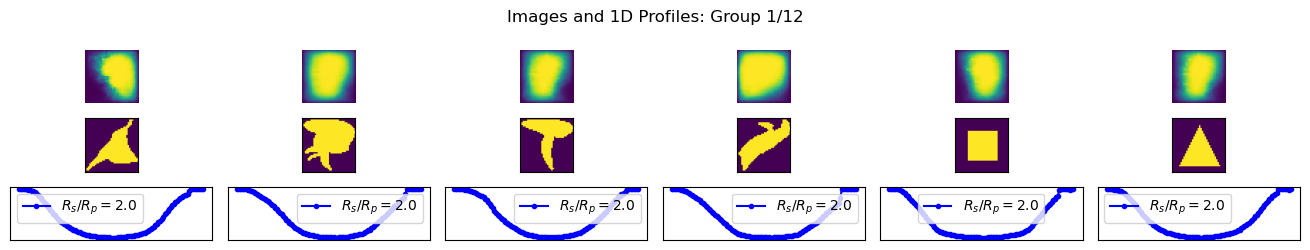

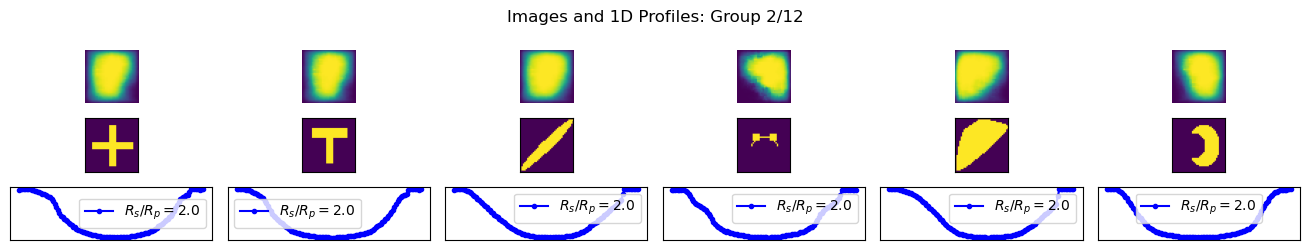

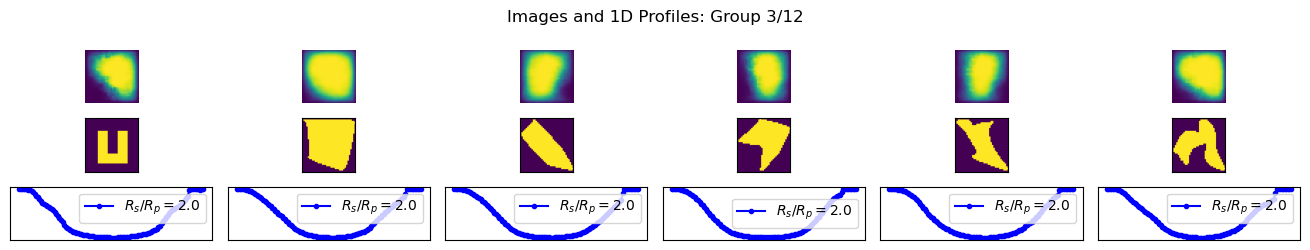

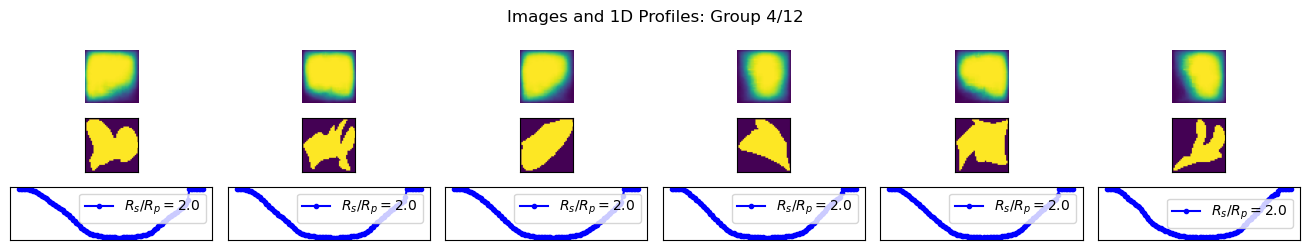

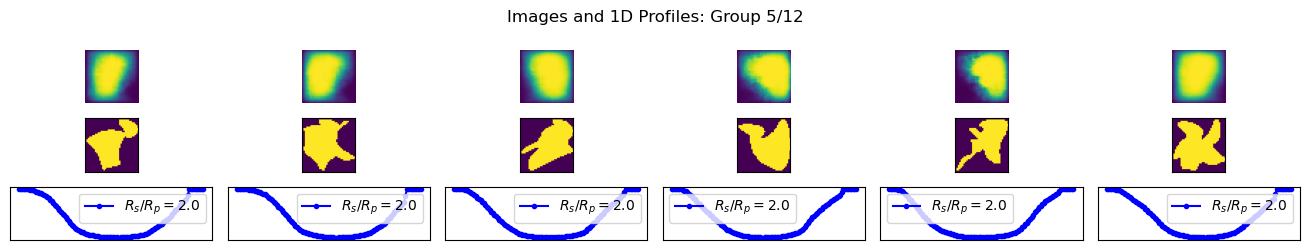

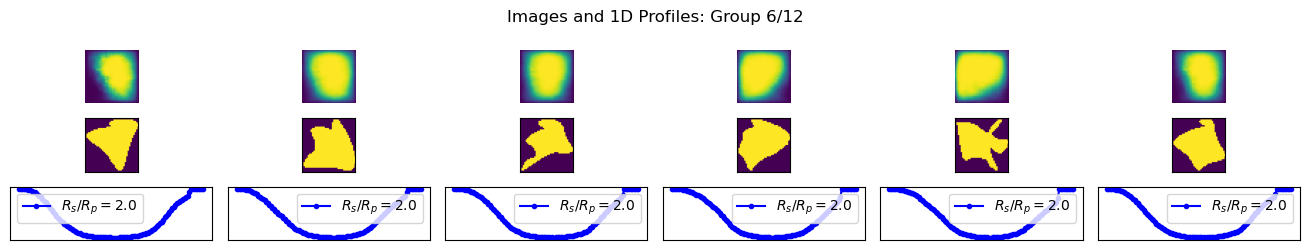

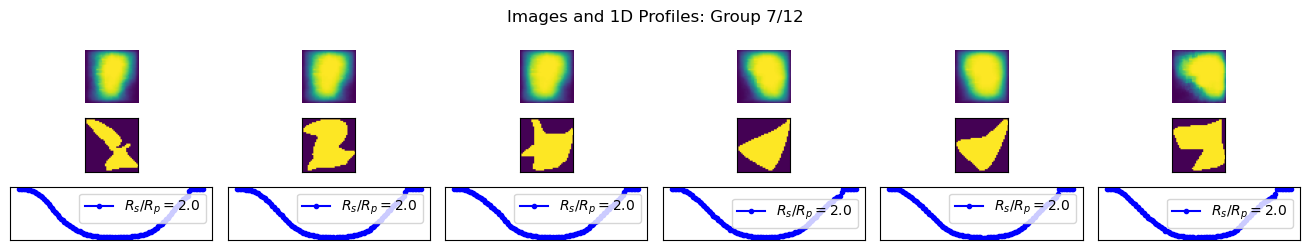

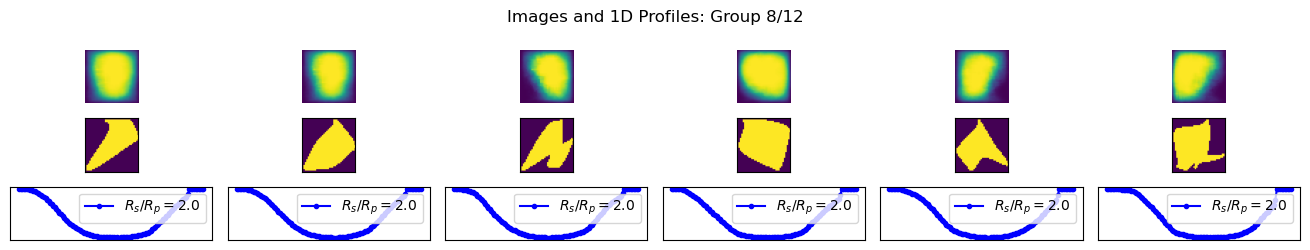

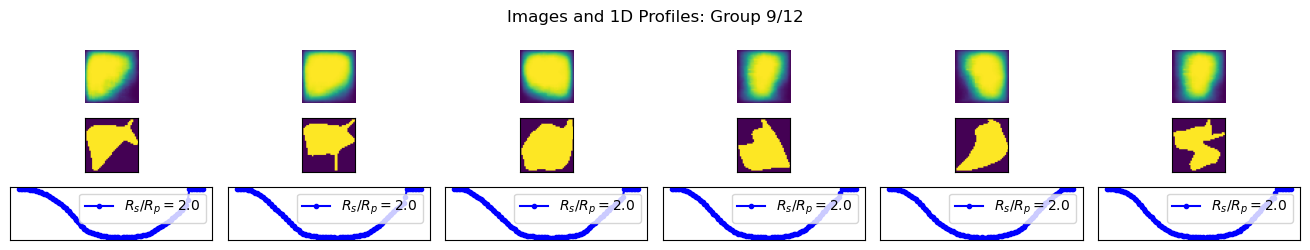

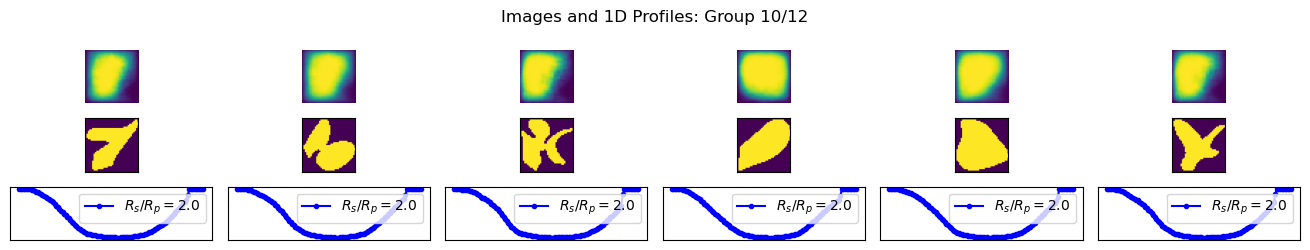

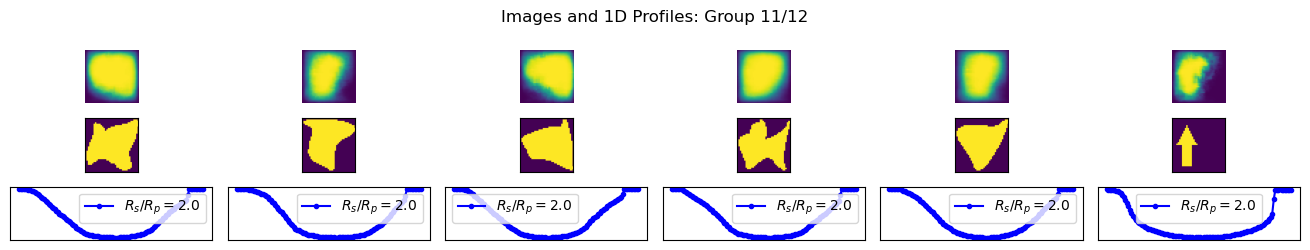

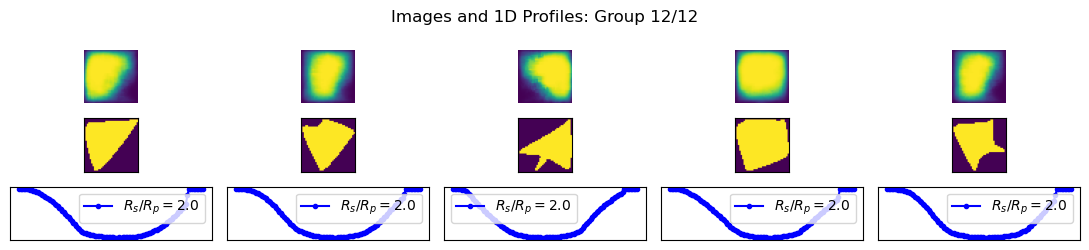

In [23]:
# plot the predictions

snr = snr_values[0]
out_filename = f"/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/ml_model_test_files/test_shapes_noncirc_circ_both_shapesLC_hscaled_processed_snr{snr}_PredctdShape.npy"
org_shapes_file = "/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/ml_model_test_files/test_shapes_noncirc_circ_both_shapes.npy"
meta_file = "/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/ml_model_test_files/test_shapes_noncirc_circ_both_shapes_meta.npy"
ltcrvs_noisy_file = f"/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/ml_model_test_files/test_shapes_noncirc_circ_both_shapesLC_hscaled_processed_snr{snr}.npy"

predicted_shape = np.load(out_filename)
org_shapes = np.load(org_shapes_file)
meta_data = np.load(meta_file)
ltcrvs_noisy = np.load(ltcrvs_noisy_file)

sort_idx = np.argsort(meta_data[:, 2]) # sort the Rs/Rp in increasing order

meta_data_sorted = meta_data[sort_idx]
predicted_shape_sorted = predicted_shape[sort_idx]
org_shapes_sorted = org_shapes[sort_idx]
ltcrvs_noisy_sorted = ltcrvs_noisy[sort_idx]

images = predicted_shape_sorted#predicted_shape
predictions = org_shapes_sorted #org_shapes
profiles = ltcrvs_noisy_sorted

n_total = images.shape[0]-200
n_cols = 6                               # number of images per row
n_groups = int(np.ceil(n_total / n_cols))  # number of full groups

for group in range(n_groups):
    start = group * n_cols
    end = min(start + n_cols, n_total)
    count = end - start

    fig, axes = plt.subplots(3, count, figsize=(count * 2.2, 2.5), constrained_layout=True)

    for i in range(count):
        # Plot image
        ax_img = axes[0, i] if count > 1 else axes[0]
        ax_img.imshow(images[start + i], cmap='viridis')
        #ax_img.set_title(f"{kepnames[start + i]}\n$R_p/R_s$: {rp_rs_ratio[start + i]:.2f}\n$snr$: {snr[start + i]:.2f}", fontsize=8)
        ax_img.axis('off')

        # Plot 1D profile
        ax_pred = axes[1, i] if count > 1 else axes[1]
        ax_pred.imshow(predictions[start + i], cmap='viridis')
        ax_pred.set_xticks([])
        ax_pred.set_yticks([])

        # Plot 1D profile
        ax_prof = axes[2, i] if count > 1 else axes[1]
        ax_prof.plot(profiles[start + i], '.-b', label=rf'$R_s/R_p={meta_data_sorted[start + i,2]}$')
        ax_prof.set_xticks([])
        ax_prof.set_yticks([])
        ax_prof.legend()
        

    plt.suptitle(f"Images and 1D Profiles: Group {group+1}/{n_groups}", fontsize=12)
    plt.tight_layout()
    plt.savefig('/home/iit-t/Gitika/Github-Repositories/Abraham_Mega/Reanalysis_Git/Mega_PartII_Kepler/figures/predictions_test.png')
    plt.show()